# Baseline Logistic Model Interpretation

This notebook extracts the fitted logistic regression coefficients from the complete preprocessing and modeling pipeline. Positive coefficients increase estimated default risk (`TARGET = 1`), while negative coefficients reduce it, holding other model inputs constant.

Numeric features were standardized during training, making their coefficient magnitudes more comparable. One-hot encoded coefficients represent effects relative to the omitted or alternative categories and should be interpreted with their category context.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODEL_PATH = PROJECT_ROOT / "models" / "baseline_logistic_model.joblib"
REPORT_PATH = PROJECT_ROOT / "outputs" / "reports" / "logistic_feature_importance.csv"
FIGURE_PATH = PROJECT_ROOT / "outputs" / "figures" / "logistic_feature_importance.png"

REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)

MODEL_PATH

WindowsPath('E:/ifrs9-home-credit-pd-model/models/baseline_logistic_model.joblib')

## Load the trained pipeline

In [2]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Model not found: {MODEL_PATH}. Run src/models/train_baseline_logistic.py first."
    )

model_pipeline = joblib.load(MODEL_PATH)
preprocessor = model_pipeline.named_steps["preprocessor"]
classifier = model_pipeline.named_steps["classifier"]

print("Loaded pipeline steps:", list(model_pipeline.named_steps))

Loaded pipeline steps: ['preprocessor', 'classifier']


## Extract and rank coefficients

In [3]:
transformed_feature_names = preprocessor.get_feature_names_out()
coefficients = classifier.coef_.ravel()

if len(transformed_feature_names) != len(coefficients):
    raise ValueError(
        "The number of transformed feature names does not match the number of coefficients."
    )

feature_importance = pd.DataFrame(
    {
        "transformed_feature": transformed_feature_names,
        "feature": [
            name.split("__", maxsplit=1)[-1] for name in transformed_feature_names
        ],
        "coefficient": coefficients,
    }
)
feature_importance["absolute_coefficient"] = feature_importance["coefficient"].abs()
feature_importance["odds_ratio"] = np.exp(feature_importance["coefficient"])
feature_importance["direction"] = np.where(
    feature_importance["coefficient"] > 0,
    "Higher risk",
    np.where(feature_importance["coefficient"] < 0, "Lower risk", "Neutral"),
)
feature_importance = feature_importance.sort_values(
    "absolute_coefficient", ascending=False
).reset_index(drop=True)
feature_importance.insert(0, "absolute_rank", feature_importance.index + 1)

feature_importance.to_csv(REPORT_PATH, index=False)
print(f"Saved {len(feature_importance):,} coefficient records to {REPORT_PATH}")
feature_importance.head(10)

Saved 297 coefficient records to E:\ifrs9-home-credit-pd-model\outputs\reports\logistic_feature_importance.csv


,absolute_rank,transformed_feature,feature,coefficient,absolute_coefficient,odds_ratio,direction
0,1,categorical__ORGANIZATION_TYPE_XNA,ORGANIZATION_TYPE_XNA,-6.134310,6.134310,0.002167,Lower risk
1,2,numeric__DAYS_EMPLOYED,DAYS_EMPLOYED,5.696227,5.696227,297.741917,Higher risk
2,3,categorical__NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_Pensioner,-4.059171,4.059171,0.017263,Lower risk
3,4,categorical__NAME_INCOME_TYPE_Working,NAME_INCOME_TYPE_Working,2.283596,2.283596,9.811901,Higher risk
4,5,categorical__NAME_INCOME_TYPE_Commercial assoc...,NAME_INCOME_TYPE_Commercial associate,2.222506,2.222506,9.230438,Higher risk
5,6,categorical__NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_State servant,2.193704,2.193704,8.968366,Higher risk
6,7,categorical__NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Unemployed,-2.093050,2.093050,0.123310,Lower risk
7,8,categorical__NAME_EDUCATION_TYPE_Academic degree,NAME_EDUCATION_TYPE_Academic degree,-1.250248,1.250248,0.286434,Lower risk
8,9,numeric__bureau_loan_count,bureau_loan_count,-0.953123,0.953123,0.385535,Lower risk
9,10,numeric__FLAG_EMP_PHONE,FLAG_EMP_PHONE,0.920370,0.920370,2.510219,Higher risk


## Top 30 positive risk drivers

These features have the largest positive coefficients and therefore increase the model's estimated log-odds of default.

In [4]:
top_positive = (
    feature_importance.loc[feature_importance["coefficient"] > 0]
    .nlargest(30, "coefficient")
    .reset_index(drop=True)
)
top_positive[["feature", "coefficient", "odds_ratio"]]

,feature,coefficient,odds_ratio
0,DAYS_EMPLOYED,5.696227,297.741917
1,NAME_INCOME_TYPE_Working,2.283596,9.811901
2,NAME_INCOME_TYPE_Commercial associate,2.222506,9.230438
3,NAME_INCOME_TYPE_State servant,2.193704,8.968366
4,FLAG_EMP_PHONE,0.920370,2.510219
5,AMT_CREDIT,0.866507,2.378588
6,ORGANIZATION_TYPE_Legal Services,0.836808,2.308984
7,ORGANIZATION_TYPE_Realtor,0.834701,2.304124
8,pos_cash_max_instalment,0.800591,2.226856
9,ORGANIZATION_TYPE_Transport: type 3,0.692462,1.998631


## Top 30 negative risk drivers

These features have the most negative coefficients and therefore reduce the model's estimated log-odds of default.

In [5]:
top_negative = (
    feature_importance.loc[feature_importance["coefficient"] < 0]
    .nsmallest(30, "coefficient")
    .reset_index(drop=True)
)
top_negative[["feature", "coefficient", "odds_ratio"]]

,feature,coefficient,odds_ratio
0,ORGANIZATION_TYPE_XNA,-6.134310,0.002167
1,NAME_INCOME_TYPE_Pensioner,-4.059171,0.017263
2,NAME_INCOME_TYPE_Unemployed,-2.093050,0.123310
3,NAME_EDUCATION_TYPE_Academic degree,-1.250248,0.286434
4,bureau_loan_count,-0.953123,0.385535
5,AMT_GOODS_PRICE,-0.895659,0.408338
6,ORGANIZATION_TYPE_Trade: type 5,-0.830921,0.435648
7,ORGANIZATION_TYPE_Trade: type 4,-0.642961,0.525733
8,pos_cash_max_future_instalments,-0.615812,0.540202
9,pos_cash_mean_instalment,-0.562309,0.569891


## Feature importance plot

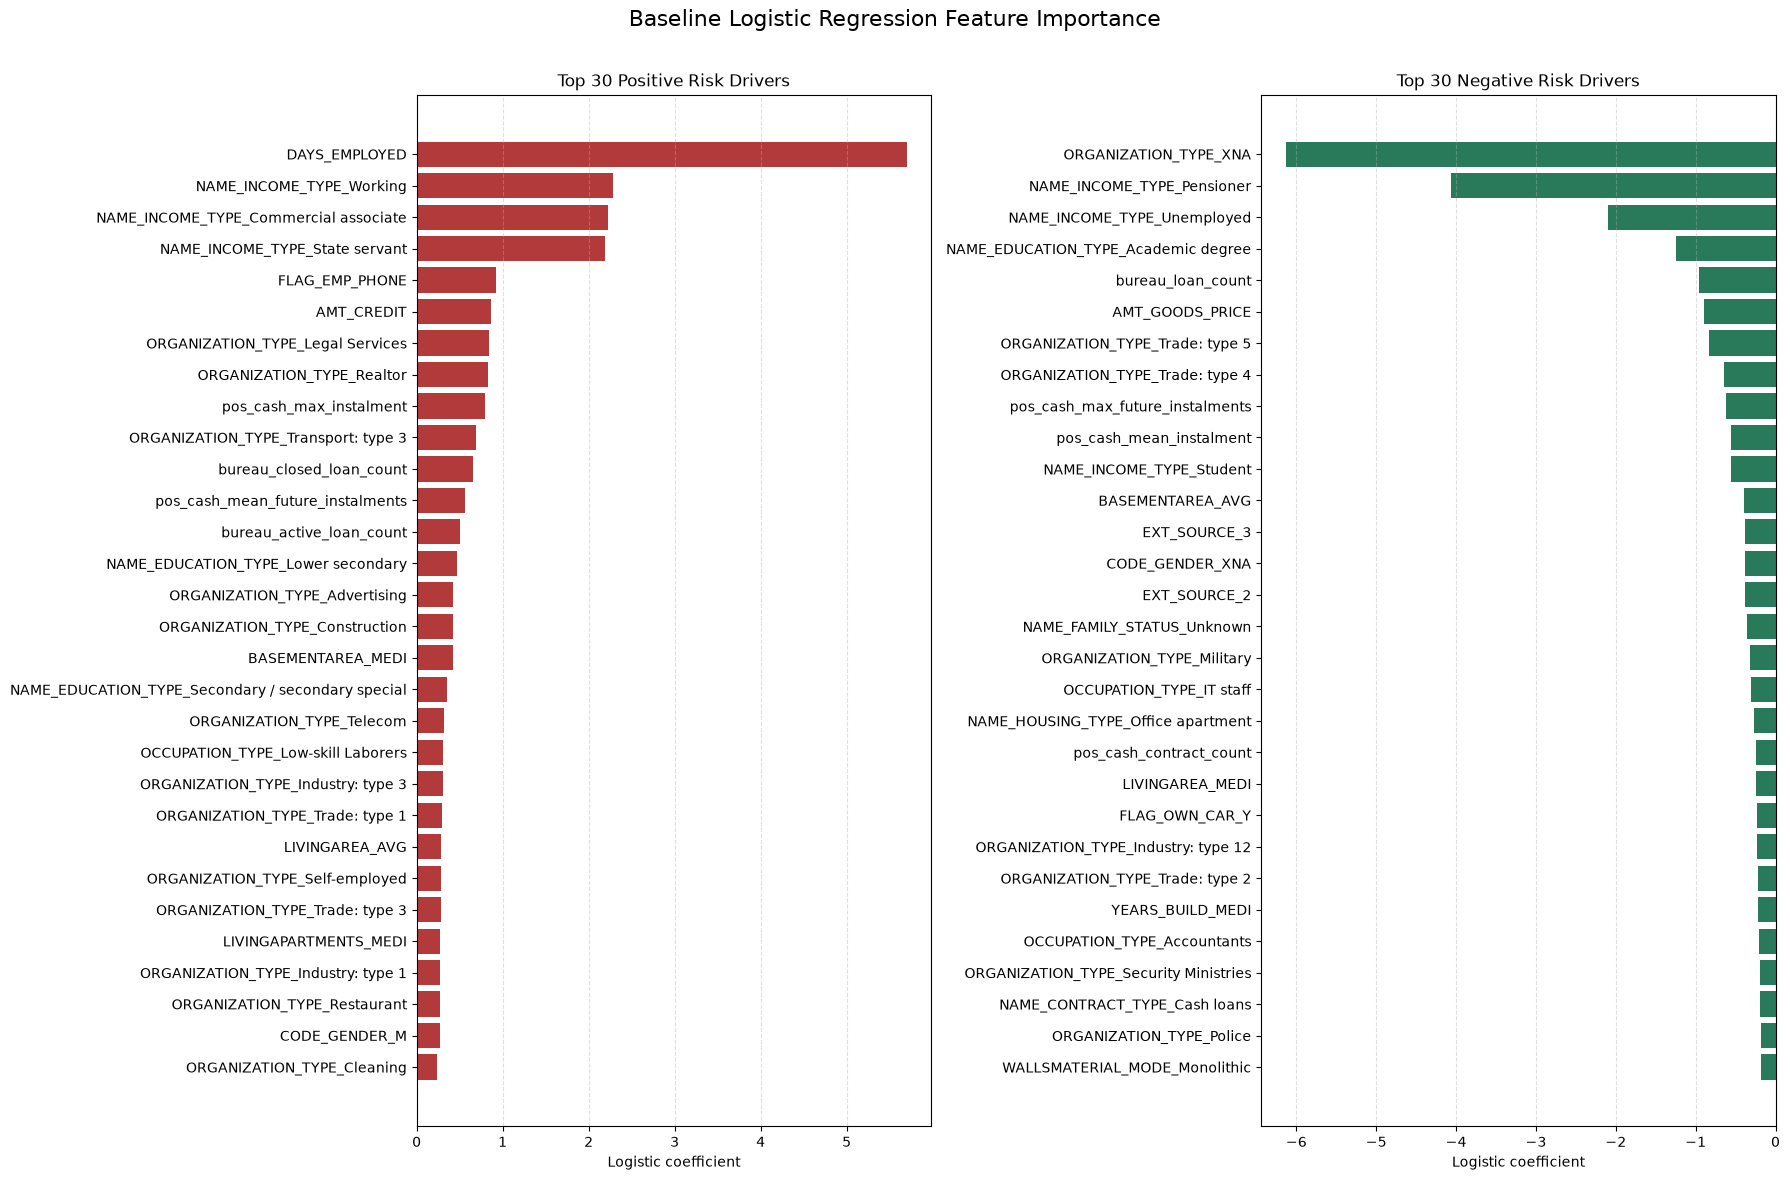

Saved plot to E:\ifrs9-home-credit-pd-model\outputs\figures\logistic_feature_importance.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 12))

positive_plot = top_positive.sort_values("coefficient")
axes[0].barh(positive_plot["feature"], positive_plot["coefficient"], color="#B33A3A")
axes[0].set_title("Top 30 Positive Risk Drivers")
axes[0].set_xlabel("Logistic coefficient")
axes[0].set_ylabel("")
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

negative_plot = top_negative.sort_values("coefficient", ascending=False)
axes[1].barh(negative_plot["feature"], negative_plot["coefficient"], color="#287A5B")
axes[1].set_title("Top 30 Negative Risk Drivers")
axes[1].set_xlabel("Logistic coefficient")
axes[1].set_ylabel("")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

fig.suptitle("Baseline Logistic Regression Feature Importance", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot to {FIGURE_PATH}")

## Interpretation considerations

- Coefficients describe associations learned by the model, not causal effects.
- Positive coefficients are associated with higher predicted default risk; negative coefficients are associated with lower predicted risk.
- An odds ratio above 1 indicates increased odds of default, while an odds ratio below 1 indicates reduced odds.
- Correlated predictors can distribute or destabilize coefficient magnitude across related variables.
- One-hot encoded category effects should be reviewed against the other categories of the same original variable.